# Tokenization in LLMs

Tokenization is the process of breaking raw text into smaller units called **tokens** — the fundamental input unit for language models. Everything an LLM reads and generates passes through this layer.

---

## 1. What Is a Token?

A token is not always a word. Depending on the tokenizer, a token can be:

- A whole word: `cat`
- A sub-word: `un`, `happy`, `ness`
- A single character: `c`, `a`, `t`
- Punctuation or whitespace: `.`, `,`, `\n`
- Special symbols: `<|endoftext|>`, `[CLS]`, `[SEP]`

> **Rule of thumb:** 1 token ≈ 4 characters or ¾ of a word in English. 100 tokens ≈ 75 words.

---

## 2. Types of Tokenization

| Method | Unit | OOV Handling | Used In |
|---|---|---|---|
| Word-level | Whole words | `<UNK>` token | Early NLP |
| Character-level | Single chars | None (full coverage) | Some seq2seq models |
| Sub-word (BPE) | Sub-words | Decomposes unknown words | GPT series |
| WordPiece | Sub-words | Decomposes unknown words | BERT, DistilBERT |
| SentencePiece | Sub-words + raw bytes | Language-agnostic | T5, LLaMA, Gemini |
| Unigram LM | Sub-words (probabilistic) | Decomposes unknown words | Some multilingual models |

---

## 3. Sub-word Tokenization (The Modern Standard)

Sub-word tokenization strikes a balance between vocabulary size and sequence length. It breaks rare or unknown words into smaller known pieces while keeping common words intact.

### Example

```
"unhappiness"  →  ["un", "happy", "ness"]
"tokenization" →  ["token", "ization"]
"ChatGPT"      →  ["Chat", "G", "PT"]
"COVID-19"     →  ["CO", "VID", "-", "19"]
```

### Why It Works

- Common words stay as single tokens → efficient
- Rare/new words get decomposed → no information loss
- Morphological structure is partially preserved (`play`, `playing`, `player`)

---

## 4. OOV — Out of Vocabulary

### The Old Problem

In word-level tokenizers, any word not seen during vocabulary construction was replaced with a single `<UNK>` token, destroying all semantic signal.

```
"The antidisestablishmentarianism debate..."
→ "The <UNK> debate..."   ← all meaning lost
```

### How Sub-word Solves It

Sub-word tokenizers virtually eliminate OOV. Any unknown word can be decomposed into known sub-pieces or, at worst, individual characters:

```
"antidisestablishmentarianism"
→ ["anti", "dis", "establish", "ment", "arian", "ism"]
```

### Byte-Level Fallback (BPE-Byte)

GPT-2 and GPT-4 use **byte-level BPE**, which encodes text at the byte level before building sub-word pairs. This guarantees zero OOV — every possible byte sequence (0–255) is always representable.

---

## 5. Major Tokenization Algorithms

### BPE — Byte Pair Encoding

Used by: GPT-2, GPT-3, GPT-4, RoBERTa

1. Start with a character-level vocabulary
2. Repeatedly merge the most frequent adjacent pair
3. Continue until vocabulary size is reached

```
"low", "low", "lower", "newer", "wider"

Step 1: l o w  →  merge "l"+"o" → "lo"
Step 2: lo w   →  merge "lo"+"w" → "low"
...
```

### WordPiece

Used by: BERT, DistilBERT, ELECTRA

Similar to BPE, but merges based on maximizing language model likelihood rather than raw frequency. Prefixes sub-word continuations with `##`:

```
"playing"  →  ["play", "##ing"]
"unhappy"  →  ["un", "##happy"]
```

### SentencePiece

Used by: T5, LLaMA, Gemini, Mistral

- Treats text as a raw character stream (no pre-tokenization by whitespace)
- Language-agnostic — works well for Chinese, Japanese, Arabic, etc.
- Can use either BPE or Unigram LM as the underlying algorithm
- Encodes spaces as a special character `▁` (underscore-like)

```
"Hello world"  →  ["▁Hello", "▁world"]
```

### Unigram Language Model

Used by: Some multilingual models, XLNet

- Starts with a large vocabulary and prunes it
- Assigns probabilities to all possible segmentations of a word
- Chooses the most likely segmentation (probabilistic, not deterministic)

---

## 6. Special Tokens

LLMs use reserved tokens to communicate structure and control:

| Token | Purpose | Example Models |
|---|---|---|
| `[CLS]` | Classification marker (start) | BERT |
| `[SEP]` | Sentence separator | BERT |
| `[PAD]` | Padding to equal length | BERT |
| `[MASK]` | Masked token for MLM training | BERT |
| `<\|endoftext\|>` | Document boundary | GPT-2/3 |
| `<s>`, `</s>` | Start/end of sequence | LLaMA, T5 |
| `<\|system\|>`, `<\|user\|>` | Chat role delimiters | Chat-tuned models |
| `<unk>` | Unknown token fallback | Most models |

These tokens are embedded like any other token but carry special semantic meaning during training.

---

## 7. Vocabulary Size

The vocabulary is the fixed set of all known tokens. Typical sizes:

| Model | Vocabulary Size |
|---|---|
| BERT | 30,522 |
| GPT-2 | 50,257 |
| GPT-4 / tiktoken (cl100k) | 100,277 |
| LLaMA 2 | 32,000 |
| LLaMA 3 | 128,256 |
| T5 | 32,100 |

**Larger vocabulary → fewer tokens per sentence → shorter sequences → faster inference**, but requires a larger embedding matrix.

---

## 8. Token Count and Context Window

Every LLM has a maximum **context window** measured in tokens (not words or characters):

```
GPT-4o:      128,000 tokens
Claude 3.5:  200,000 tokens
Gemini 1.5:  1,000,000 tokens
LLaMA 3:     8,192 tokens (base)
```

Token count directly affects:
- **Cost** — APIs charge per token
- **Latency** — longer sequences take more time
- **Memory** — attention scales as O(n²) with sequence length
- **Truncation** — inputs beyond the context limit are cut off

---

## 9. Tokenization Quirks and Pitfalls

### Capitalization Changes Tokens

```
"hello"  →  1 token
"Hello"  →  1 token (different token)
"HELLO"  →  1 token (another different token)
```

### Leading Space Matters

```
"dog"   →  token ID 3190
" dog"  →  token ID  645   ← different token!
```

This is why SentencePiece encodes the space as `▁` explicitly.

### Numbers Are Split

```
"1000000"  →  ["100", "000", "0"]   or   ["1", "000", "000"]
```

This is why LLMs can struggle with arithmetic — numbers aren't treated holistically.

### Non-English Languages Are Penalized

Languages with fewer training samples have larger tokens per word ratios. English is highly compressed; languages like Thai, Arabic, or code-switching text can use 3–5x more tokens for the same information content.

```
"Hello"    →  1 token    (English)
"Bonjour"  →  2 tokens   (French)
"สวัสดี"   →  7 tokens   (Thai)
```

---

## 10. Tokenization in Training vs. Inference

| Phase | Role of Tokenizer |
|---|---|
| **Pre-training** | Entire corpus is tokenized offline; model learns embeddings for each token ID |
| **Fine-tuning** | Same tokenizer is reused — vocabulary is frozen |
| **Inference** | Input is tokenized → token IDs fed to model → output token IDs decoded back to text |
| **RLHF / alignment** | Reward model also operates on token sequences |

> **Critical:** The tokenizer is trained separately from the model (e.g., using BPE on a large corpus), then frozen. The model only ever sees integer token IDs, never raw text.

---

## 11. The Core Trade-off (Revisited)

```
Granularity:  Word ──────────────────────── Character
              ↑                              ↑
         OOV problem                  Too many tokens
         Vocab too large              Loses morphology
         Can't generalize

                    Sub-word ← sweet spot
                    (BPE / WordPiece / SentencePiece)
```

The ideal tokenizer:
- Minimizes sequence length (fewer tokens = faster, cheaper)
- Maximizes coverage (no OOV, multilingual support)
- Preserves semantic coherence (whole words when common, logical splits when rare)

---

## 12. Quick Reference

```
Text → Tokenizer → [token_id_1, token_id_2, ...] → Embedding Layer → Transformer
                                                                            ↓
Text ← Detokenizer ← [token_id_1, token_id_2, ...] ←────── Softmax over vocabulary
```

| Concept | Key Point |
|---|---|
| Token | Basic unit of text for the model |
| Vocabulary | Fixed set of all known tokens (frozen after training) |
| BPE | Merge frequent pairs; used by GPT series |
| WordPiece | Maximize likelihood; used by BERT |
| SentencePiece | Language-agnostic, raw stream; used by LLaMA/T5 |
| OOV | Solved by sub-word decomposition |
| Context window | Max tokens a model can process at once |
| Special tokens | Structural control tokens (`[CLS]`, `<\|endoftext\|>`, etc.) |

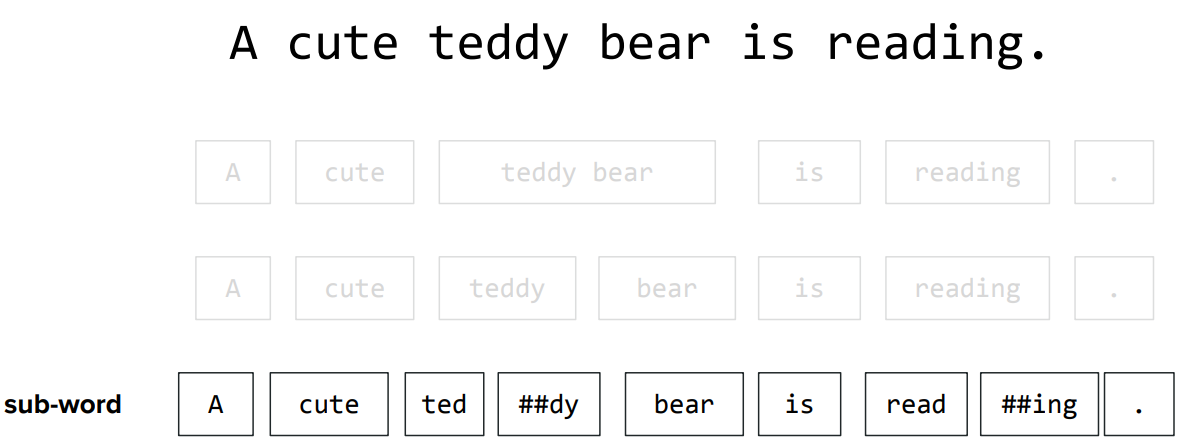

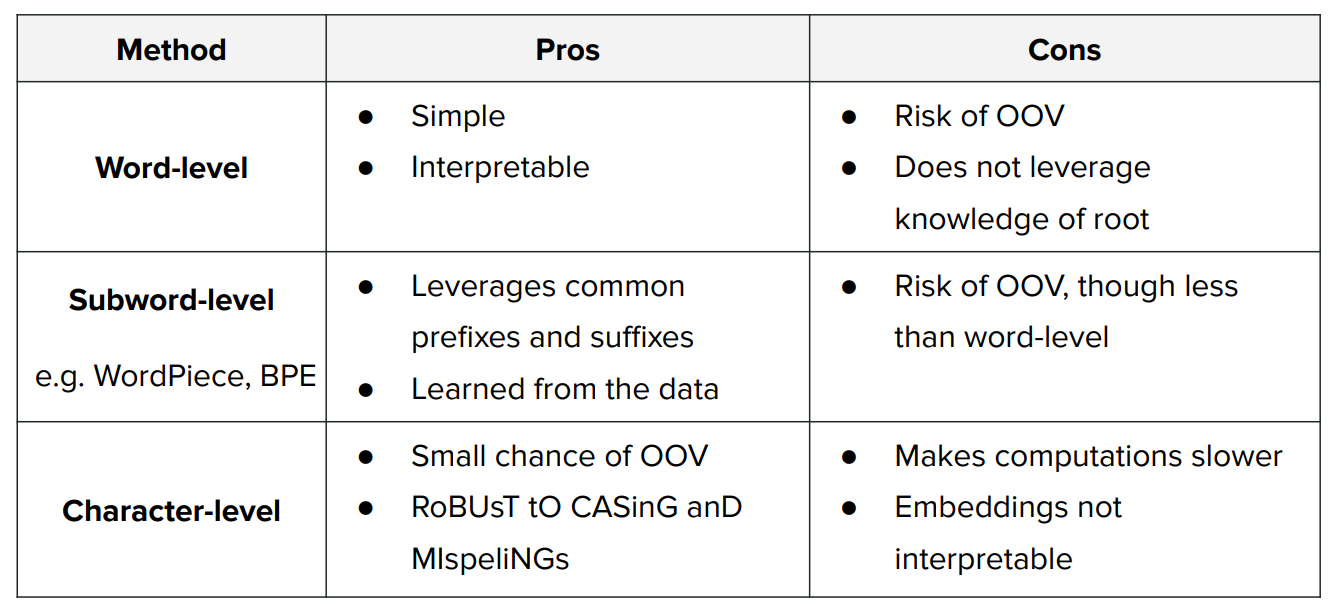